In [1]:
!pip install cvxpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import linprog
import cvxpy as cp
import warnings
warnings.filterwarnings('ignore')


In [2]:
k = 6
epsilon = 0.05 + 0.05 * (k % 3)
print(f"Параметры неопределённости: δ = {delta}, ε = {epsilon}")


Параметры неопределённости: δ = 0.05, ε = 0.05


In [3]:
np.random.seed(42)
n_weeks = 12
n_skus = 10
sku_ids = [f"SKU_{i+1}" for i in range(n_skus)]

# Базовые параметры для каждого SKU
base_sales = np.random.uniform(50, 500, n_skus)
trend_factor = np.random.uniform(-0.03, 0.05, n_skus)  # недельный тренд
noise_level = np.random.uniform(0.1, 0.3, n_skus)
return_rate_base = np.random.uniform(0.02, 0.15, n_skus)

data = []
for i, sku in enumerate(sku_ids):
    for week in range(1, n_weeks+1):
        # Объём продаж с трендом и шумом
        sales = base_sales[i] * (1 + trend_factor[i] * week) * np.random.normal(1, noise_level[i])
        sales = max(0, int(sales))
        # Возвраты как доля от продаж + случайность
        returns = int(sales * return_rate_base[i] * np.random.uniform(0.5, 1.5))
        returns = min(returns, sales)  # не больше продаж
        data.append([sku, week, sales, returns])

df_sales = pd.DataFrame(data, columns=['sku_id', 'week', 'sales_t', 'returns_t'])
print("Исходные данные (первые 5 строк):")
print(df_sales.head())
print(f"Всего SKU: {df_sales['sku_id'].nunique()}, недель: {df_sales['week'].nunique()}")

# Проверка пропусков и дубликатов
print("Пропуски:\n", df_sales.isnull().sum())
print("Дубликаты (sku, week):", df_sales.duplicated(subset=['sku_id', 'week']).sum())

Исходные данные (первые 5 строк):
  sku_id  week  sales_t  returns_t
0  SKU_1     1      211         11
1  SKU_1     2      157         21
2  SKU_1     3      236         18
3  SKU_1     4      141         14
4  SKU_1     5      132         19
Всего SKU: 10, недель: 12
Пропуски:
 sku_id       0
week         0
sales_t      0
returns_t    0
dtype: int64
Дубликаты (sku, week): 0


In [4]:
criteria = []

for sku in sku_ids:
    sku_data = df_sales[df_sales['sku_id'] == sku]
    sales = sku_data['sales_t'].values
    returns = sku_data['returns_t'].values

    # 1. Средний объём продаж (max)
    mean_sales = np.mean(sales)

    # 2. Средняя доля возвратов (min)
    total_sales = np.sum(sales)
    total_returns = np.sum(returns)
    return_rate = total_returns / total_sales if total_sales > 0 else 0

    # 3. Стабильность продаж: стандартное отклонение (min)
    std_sales = np.std(sales)

    # 4. Прогнозируемость: MAE простого линейного прогноза по первым 8 неделям
    #    Обучаем на неделях 1..8, тест 9..12
    weeks = np.arange(1, len(sales)+1)
    train_weeks = weeks[:8]
    train_sales = sales[:8]
    if len(train_sales) >= 3:
        slope, intercept = np.polyfit(train_weeks, train_sales, 1)
        pred_sales = slope * weeks[8:] + intercept
        mae = np.mean(np.abs(pred_sales - sales[8:]))
    else:
        mae = np.nan

    # 5. Тренд продаж: наклон линейного тренда по всем неделям (max)
    slope_full, _ = np.polyfit(weeks, sales, 1)

    criteria.append({
        'sku_id': sku,
        'mean_sales': mean_sales,
        'return_rate': return_rate,
        'std_sales': std_sales,
        'mae': mae,
        'trend_slope': slope_full
    })

df_criteria = pd.DataFrame(criteria)
print("\nРассчитанные критерии (сырые значения):")
print(df_criteria)

# Замена пропусков в mae на медиану (если есть)
df_criteria['mae'].fillna(df_criteria['mae'].median(), inplace=True)



Рассчитанные критерии (сырые значения):
   sku_id  mean_sales  return_rate   std_sales        mae  trend_slope
0   SKU_1  171.666667     0.087864   31.639462  20.642857    -3.398601
1   SKU_2  641.416667     0.042224  111.890913  67.773810    27.765734
2   SKU_3  476.000000     0.029587   68.423924  52.761905    14.167832
3   SKU_4  288.583333     0.141496   34.230733  56.660714    -4.849650
4   SKU_5  109.333333     0.116616   25.936889  48.642857    -2.000000
5   SKU_6  100.916667     0.126342   26.304177  14.446429     0.094406
6   SKU_7   75.916667     0.053787    7.631714   5.934524     0.003497
7   SKU_8  477.166667     0.032658   72.875274  58.363095     8.174825
8   SKU_9  313.750000     0.129084   63.328673  94.000000     7.248252
9  SKU_10  375.000000     0.080444   57.259643  54.250000    -6.909091


In [5]:
def normalize(series, maximize=True):
    if series.max() == series.min():
        return pd.Series([1.0] * len(series))
    if maximize:
        return (series - series.min()) / (series.max() - series.min())
    else:
        return (series.max() - series) / (series.max() - series.min())

df_norm = pd.DataFrame()
df_norm['sku_id'] = df_criteria['sku_id']
df_norm['mean_sales_norm'] = normalize(df_criteria['mean_sales'], maximize=True)
df_norm['return_rate_norm'] = normalize(df_criteria['return_rate'], maximize=False)
df_norm['std_sales_norm'] = normalize(df_criteria['std_sales'], maximize=False)
df_norm['mae_norm'] = normalize(df_criteria['mae'], maximize=False)
df_norm['trend_slope_norm'] = normalize(df_criteria['trend_slope'], maximize=True)

print("\nНормированные критерии (полезности по каждому критерию):")
print(df_norm.round(3))



Нормированные критерии (полезности по каждому критерию):
   sku_id  mean_sales_norm  return_rate_norm  std_sales_norm  mae_norm  \
0   SKU_1            0.169             0.479           0.770     0.833   
1   SKU_2            1.000             0.887           0.000     0.298   
2   SKU_3            0.707             1.000           0.417     0.468   
3   SKU_4            0.376             0.000           0.745     0.424   
4   SKU_5            0.059             0.222           0.824     0.515   
5   SKU_6            0.044             0.135           0.821     0.903   
6   SKU_7            0.000             0.784           1.000     1.000   
7   SKU_8            0.710             0.973           0.374     0.405   
8   SKU_9            0.421             0.111           0.466     0.000   
9  SKU_10            0.529             0.546           0.524     0.451   

   trend_slope_norm  
0             0.101  
1             1.000  
2             0.608  
3             0.059  
4             0.1

In [6]:
# Номинальные веса критериев
w_nom = np.array([0.30, 0.20, 0.20, 0.15, 0.15])
# Матрица полезностей (альтернативы x критерии)
U_nom = df_norm.iloc[:, 1:].values  # n_skus x m

# Целевая полезность альтернативы i: v_i = U_nom[i] @ w_nom
v_nom = U_nom @ w_nom

# Решение задачи линейного программирования:
# max sum_i x_i * v_i
# при x_i >=0, sum x_i=1, x_i <=0.4
n = len(sku_ids)
x = cp.Variable(n)
objective = cp.Maximize(v_nom @ x)
constraints = [x >= 0, cp.sum(x) == 1, x <= 0.4]
prob = cp.Problem(objective, constraints)
prob.solve()

x_nom = x.value
nominal_utility = v_nom @ x_nom

print("\n=== НОМИНАЛЬНАЯ СТРАТЕГИЯ ===")
print("Вектор долей x_nom:")
for sku, val in zip(sku_ids, x_nom):
    print(f"  {sku}: {val:.3f}")
print(f"Номинальная полезность: {nominal_utility:.4f}")


=== НОМИНАЛЬНАЯ СТРАТЕГИЯ ===
Вектор долей x_nom:
  SKU_1: 0.000
  SKU_2: 0.400
  SKU_3: 0.400
  SKU_4: 0.000
  SKU_5: 0.000
  SKU_6: 0.000
  SKU_7: 0.000
  SKU_8: 0.200
  SKU_9: 0.000
  SKU_10: 0.000
Номинальная полезность: 0.6533


In [7]:
S = 50  # число сценариев (можно увеличить до 100)

# Номинальная матрица критериев (сырые значения)
M_nom = df_criteria.iloc[:, 1:].values  # n x m

# Генерация сценариев
scenarios = []  # каждый сценарий: (M_s, w_s, v_s)

for _ in range(S):
    # 1. Неопределённость критериев: m_ij ∈ [m_nom*(1-δ), m_nom*(1+δ)]
    delta_mat = np.random.uniform(1-delta, 1+delta, size=M_nom.shape)
    M_s = M_nom * delta_mat

    # 2. Нормировка критериев внутри сценария (свои min/max по альтернативам)
    U_s = np.zeros_like(M_s)
    for j in range(M_s.shape[1]):
        col = M_s[:, j]
        if col.max() == col.min():
            U_s[:, j] = 1.0
        else:
            # направление оптимизации: j=0 (mean_sales) max, j=1 return_rate min, j=2 std min, j=3 mae min, j=4 trend max
            if j in [0,4]:  # максимизировать
                U_s[:, j] = (col - col.min()) / (col.max() - col.min())
            else:           # минимизировать
                U_s[:, j] = (col.max() - col) / (col.max() - col.min())

    # 3. Неопределённость весов: w в L1-шаре радиуса ε вокруг w_nom
    #    Генерируем случайное направление, нормализуем и масштабируем
    while True:
        dw = np.random.uniform(-epsilon, epsilon, size=len(w_nom))
        if np.sum(np.abs(dw)) <= epsilon:
            w_s = w_nom + dw
            w_s = np.clip(w_s, 0, None)  # неотрицательность
            w_s = w_s / np.sum(w_s)      # нормализация
            break

    # Полезности альтернатив в сценарии
    v_s = U_s @ w_s
    scenarios.append((U_s, w_s, v_s))

print(f"\nСгенерировано {len(scenarios)} сценариев.")


Сгенерировано 50 сценариев.


In [8]:
# Переменные: x (доли), t (гарантированная полезность)
x_rob = cp.Variable(n)
t = cp.Variable()
constraints_rob = [x_rob >= 0, cp.sum(x_rob) == 1, x_rob <= 0.4]
for (U_s, w_s, v_s) in scenarios:
    constraints_rob.append(v_s @ x_rob >= t)

objective_rob = cp.Maximize(t)
prob_rob = cp.Problem(objective_rob, constraints_rob)
prob_rob.solve()

x_rob = x_rob.value
worst_case_utility = t.value

# Средняя полезность по сценариям
utilities_rob = []
for (U_s, w_s, v_s) in scenarios:
    utilities_rob.append(v_s @ x_rob)
mean_utility_rob = np.mean(utilities_rob)

print("\n=== РОБАСТНАЯ СТРАТЕГИЯ MAX-MIN ===")
print("Вектор долей x_rob:")
for sku, val in zip(sku_ids, x_rob):
    print(f"  {sku}: {val:.3f}")
print(f"Worst-case utility: {worst_case_utility:.4f}")
print(f"Mean utility: {mean_utility_rob:.4f}")


=== РОБАСТНАЯ СТРАТЕГИЯ MAX-MIN ===
Вектор долей x_rob:
  SKU_1: -0.000
  SKU_2: 0.400
  SKU_3: 0.400
  SKU_4: -0.000
  SKU_5: -0.000
  SKU_6: -0.000
  SKU_7: 0.000
  SKU_8: 0.200
  SKU_9: -0.000
  SKU_10: -0.000
Worst-case utility: 0.6325
Mean utility: 0.6540


In [9]:
# Сначала вычислим V_s* - оптимальную полезность для каждого сценария
V_star = []
for (U_s, w_s, v_s) in scenarios:
    # Решаем max_{x in X} v_s @ x
    x_scen = cp.Variable(n)
    prob_scen = cp.Problem(cp.Maximize(v_s @ x_scen),
                           [x_scen >= 0, cp.sum(x_scen) == 1, x_scen <= 0.4])
    prob_scen.solve()
    V_star.append(prob_scen.value)

V_star = np.array(V_star)

# Теперь minimax regret: min r, при r >= V_s* - v_s @ x для всех s
x_mmr = cp.Variable(n)
r = cp.Variable()
constraints_mmr = [x_mmr >= 0, cp.sum(x_mmr) == 1, x_mmr <= 0.4]
for idx, (U_s, w_s, v_s) in enumerate(scenarios):
    constraints_mmr.append(V_star[idx] - v_s @ x_mmr <= r)

objective_mmr = cp.Minimize(r)
prob_mmr = cp.Problem(objective_mmr, constraints_mmr)
prob_mmr.solve()

x_mmr = x_mmr.value
max_regret = r.value

regrets_mmr = []
for idx, (U_s, w_s, v_s) in enumerate(scenarios):
    regret = V_star[idx] - v_s @ x_mmr
    regrets_mmr.append(regret)
mean_regret_mmr = np.mean(regrets_mmr)

print("\n=== СТРАТЕГИЯ MINIMAX REGRET ===")
print("Вектор долей x_mmr:")
for sku, val in zip(sku_ids, x_mmr):
    print(f"  {sku}: {val:.3f}")
print(f"Max regret: {max_regret:.4f}")
print(f"Mean regret: {mean_regret_mmr:.4f}")


=== СТРАТЕГИЯ MINIMAX REGRET ===
Вектор долей x_mmr:
  SKU_1: -0.000
  SKU_2: 0.400
  SKU_3: 0.400
  SKU_4: -0.000
  SKU_5: -0.000
  SKU_6: -0.000
  SKU_7: -0.000
  SKU_8: 0.200
  SKU_9: -0.000
  SKU_10: -0.000
Max regret: -0.0000
Mean regret: -0.0000


In [10]:
# Вычисляем для каждой стратегии показатели по всем сценариям
def evaluate_strategy(x_vec, name):
    utilities = []
    regrets = []
    for idx, (U_s, w_s, v_s) in enumerate(scenarios):
        u = v_s @ x_vec
        utilities.append(u)
        regret = V_star[idx] - u
        regrets.append(regret)
    return {
        'name': name,
        'mean_utility': np.mean(utilities),
        'min_utility': np.min(utilities),
        'max_regret': np.max(regrets),
        'mean_regret': np.mean(regrets),
        'utility_range': np.max(utilities) - np.min(utilities),
        'utilities': utilities,
        'regrets': regrets
    }

results = []
results.append(evaluate_strategy(x_nom, "Номинальная"))
results.append(evaluate_strategy(x_rob, "Robust Max-Min"))
results.append(evaluate_strategy(x_mmr, "Minimax Regret"))

df_comparison = pd.DataFrame([
    {k: v for k, v in res.items() if k not in ['utilities', 'regrets']}
    for res in results
])
print("\n=== СРАВНЕНИЕ СТРАТЕГИЙ ===")
print(df_comparison.round(4))



=== СРАВНЕНИЕ СТРАТЕГИЙ ===
             name  mean_utility  min_utility  max_regret  mean_regret  \
0     Номинальная         0.654       0.6325         0.0         -0.0   
1  Robust Max-Min         0.654       0.6325        -0.0         -0.0   
2  Minimax Regret         0.654       0.6325        -0.0         -0.0   

   utility_range  
0         0.0421  
1         0.0421  
2         0.0421  


In [11]:
print("\n=== ДИАГНОСТИКА УСТОЙЧИВОСТИ ===")
for res in results:
    print(f"{res['name']}:")
    print(f"  Полоса устойчивости ΔU = {res['utility_range']:.4f}")
    print(f"  Worst-case utility = {res['min_utility']:.4f}")
    print(f"  Max regret = {res['max_regret']:.4f}")
    print(f"  Mean regret = {res['mean_regret']:.4f}")



=== ДИАГНОСТИКА УСТОЙЧИВОСТИ ===
Номинальная:
  Полоса устойчивости ΔU = 0.0421
  Worst-case utility = 0.6325
  Max regret = 0.0000
  Mean regret = -0.0000
Robust Max-Min:
  Полоса устойчивости ΔU = 0.0421
  Worst-case utility = 0.6325
  Max regret = -0.0000
  Mean regret = -0.0000
Minimax Regret:
  Полоса устойчивости ΔU = 0.0421
  Worst-case utility = 0.6325
  Max regret = -0.0000
  Mean regret = -0.0000


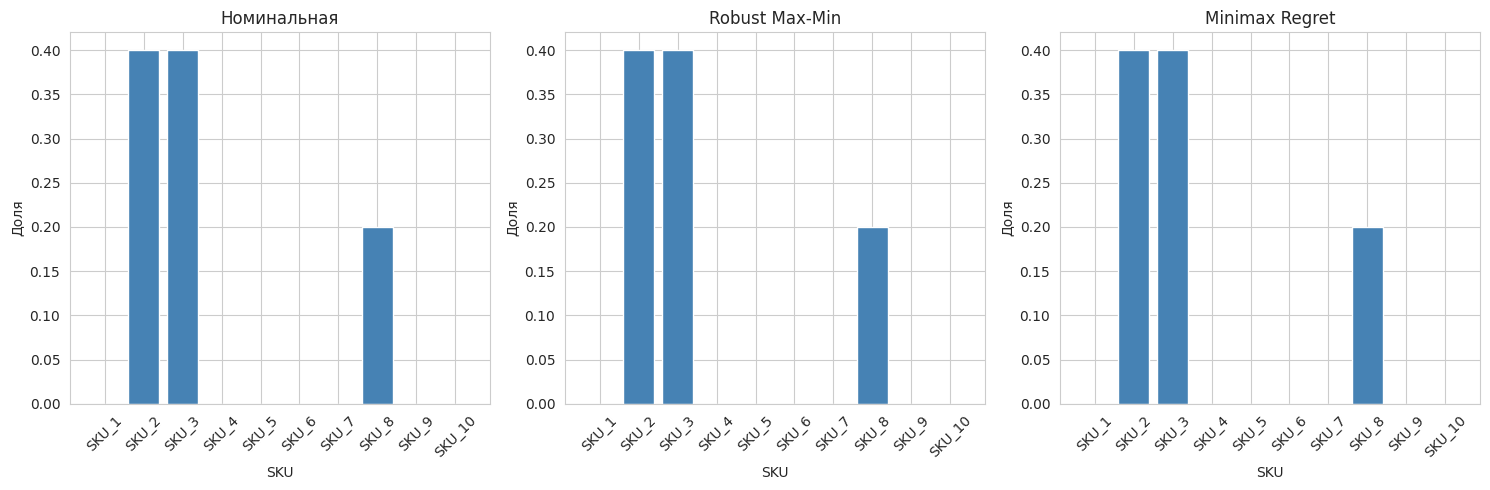

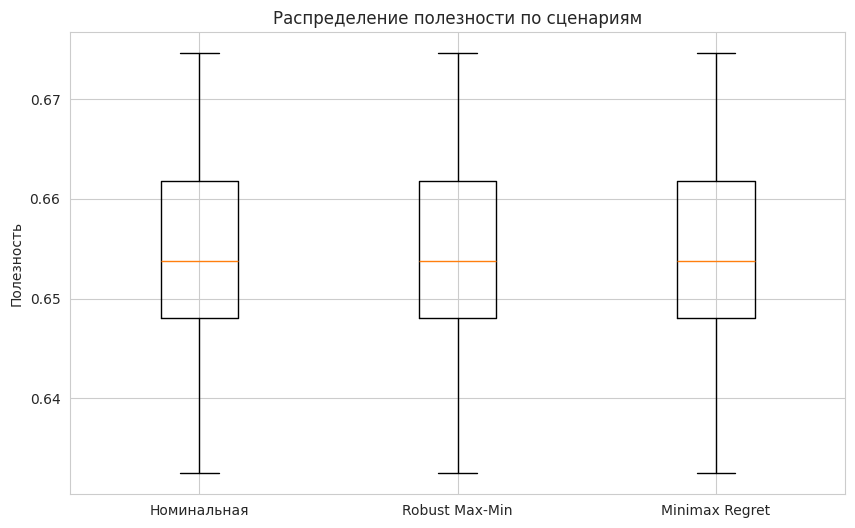

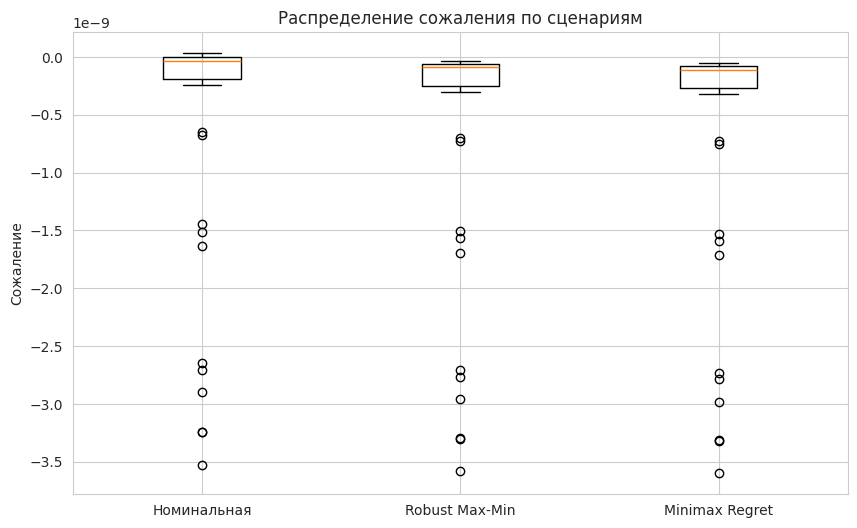

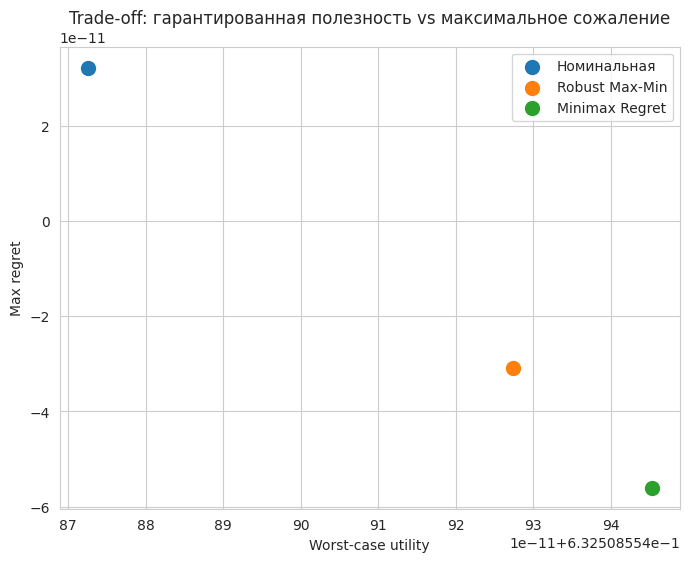

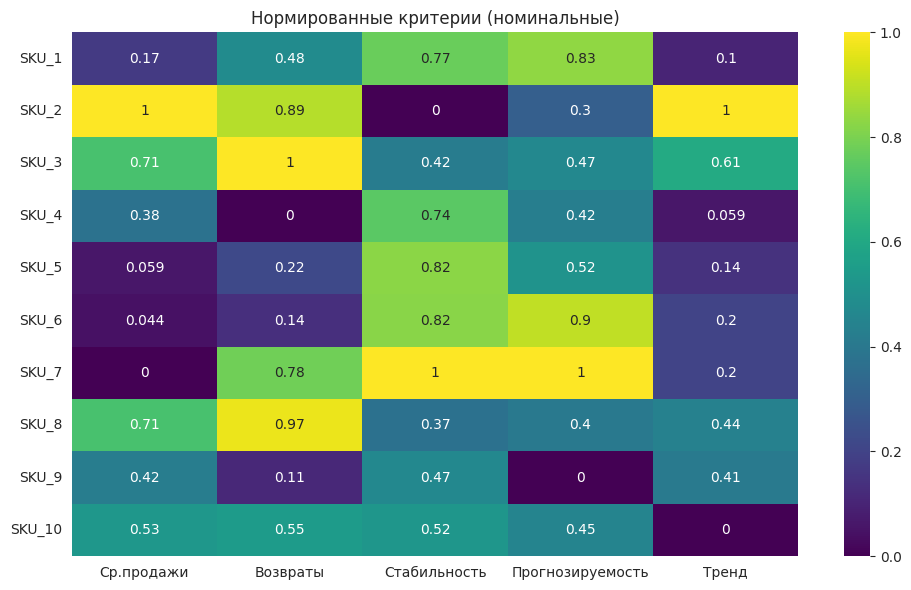

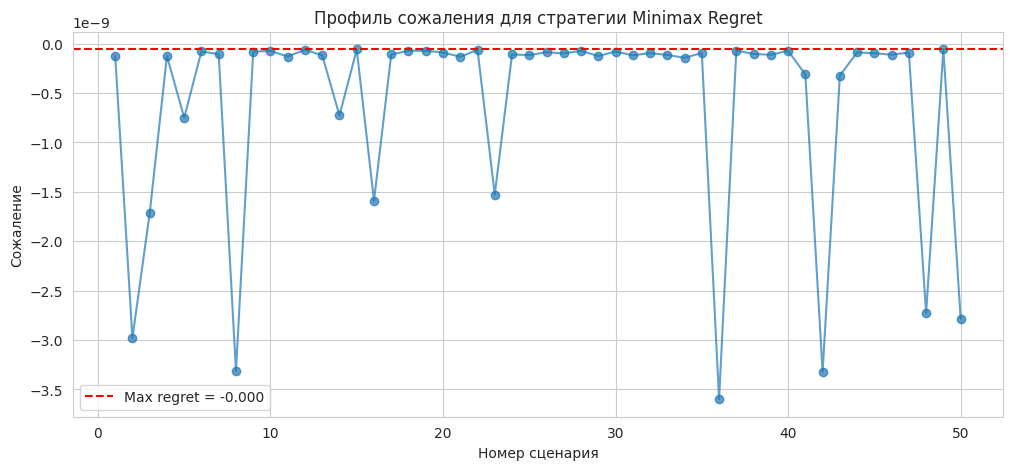

In [12]:
# Настройка стиля
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Bar chart распределения долей
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
strategy_x_values = [x_nom, x_rob, x_mmr]
for i, (ax, res) in enumerate(zip(axes, results)):
    ax.bar(sku_ids, strategy_x_values[i], color='steelblue')
    ax.set_title(res['name'])
    ax.set_xlabel("SKU")
    ax.set_ylabel("Доля")
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# 2. Boxplot полезности стратегий по сценариям
plt.figure(figsize=(10, 6))
data_utils = [res['utilities'] for res in results]
plt.boxplot(data_utils, labels=[res['name'] for res in results])
plt.title("Распределение полезности по сценариям")
plt.ylabel("Полезность")
plt.grid(True)
plt.show()

# 3. Boxplot сожаления (regret)
plt.figure(figsize=(10, 6))
data_regrets = [res['regrets'] for res in results]
plt.boxplot(data_regrets, labels=[res['name'] for res in results])
plt.title("Распределение сожаления по сценариям")
plt.ylabel("Сожаление")
plt.grid(True)
plt.show()

# 4. Scatter: worst-case utility vs max regret
plt.figure(figsize=(8, 6))
for res in results:
    plt.scatter(res['min_utility'], res['max_regret'], s=100, label=res['name'])
plt.xlabel("Worst-case utility")
plt.ylabel("Max regret")
plt.title("Trade-off: гарантированная полезность vs максимальное сожаление")
plt.legend()
plt.grid(True)
plt.show()

# 5. Heatmap нормированных критериев (номинальные)
plt.figure(figsize=(10, 6))
sns.heatmap(df_norm.iloc[:, 1:], annot=True, cmap='viridis',
            xticklabels=['Ср.продажи', 'Возвраты', 'Стабильность', 'Прогнозируемость', 'Тренд'],
            yticklabels=sku_ids)
plt.title("Нормированные критерии (номинальные)")
plt.tight_layout()
plt.show()

# 6. График профиля regret по сценариям (для стратегии minimax regret)
plt.figure(figsize=(12, 5))
plt.plot(range(1, S+1), results[2]['regrets'], 'o-', alpha=0.7)
plt.axhline(y=results[2]['max_regret'], color='r', linestyle='--', label=f"Max regret = {results[2]['max_regret']:.3f}")
plt.xlabel("Номер сценария")
plt.ylabel("Сожаление")
plt.title("Профиль сожаления для стратегии Minimax Regret")
plt.legend()
plt.grid(True)
plt.show()